## **Topic:** **Improving Neural Network Performance Through Hyperparameter Tuning: A Before-and-After Ablation Study on Fashion-MNIST**

Presented By: Sehrish Naureen



# **Step 1:** Import Libraries:


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU available: []


# **Step 2:** Loading, Splitting, and Visualizing the Fashion-MNIST Dataset

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (54000, 28, 28)  Val: (6000, 28, 28)  Test: (10000, 28, 28)


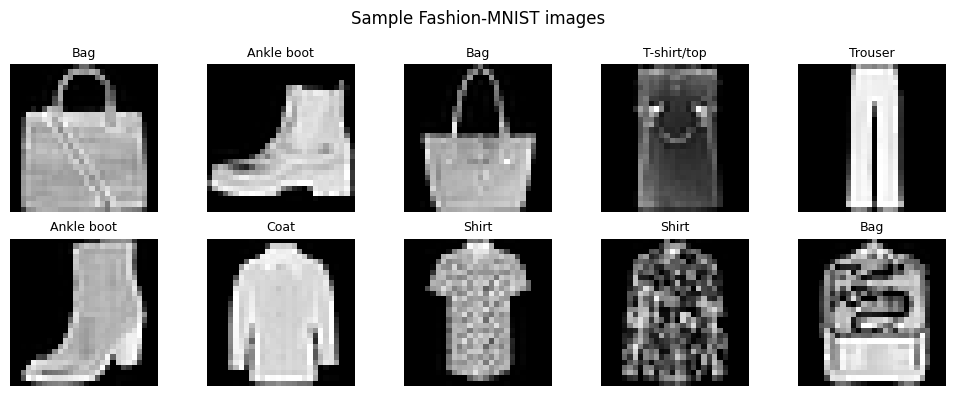

In [ ]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data() # loading the fashion MNIST Dataset directly from keras

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'] # defining the 10 different clothing catagories

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.1, random_state=SEED, stratify=y_train_full
) # splitting the training data into training and validation set

print("Train:", x_train.shape, " Val:", x_val.shape, " Test:", x_test.shape)

plt.figure(figsize=(10, 4)) # creating a fig for visulaization
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Fashion-MNIST images")
plt.tight_layout()
plt.show()

#**Step 3:** Flattening and Normalizing the Image Data

In [ ]:
def flatten(x):
    return x.reshape(x.shape[0], -1).astype('float32') # convert a two-dimensional format into a one-dimensional format

x_train_flat = flatten(x_train) # This line applies the flatten() function to the training images.
x_val_flat   = flatten(x_val) # This line applies the flatten() function to the validation images.
x_test_flat  = flatten(x_test) # This line applies the flatten() function to the testing images.

x_train_norm = x_train_flat / 255.0 #This line normalizes the training pixel values.
x_val_norm   = x_val_flat / 255.0
x_test_norm  = x_test_flat / 255.0

#**Step 4:** Building, Training, and Evaluating the Neural Network Model

In [ ]:
def build_model(input_dim=784, num_classes=10, hidden_layers=[128],
                 dropout_rate=0.0, l1_reg=0.0, l2_reg=0.0):
    reg = None # initializing the regularizer
    if l1_reg > 0 and l2_reg > 0: # checking for both L1 and L2 Regularization
        reg = regularizers.l1_l2(l1=l1_reg, l2=l2_reg)
    elif l1_reg > 0:
        reg = regularizers.l1(l1_reg)
    elif l2_reg > 0:
        reg = regularizers.l2(l2_reg)

    model = keras.Sequential() # Creating a sequential model
    model.add(layers.Input(shape=(input_dim,)))
    for n_neurons in hidden_layers:
        model.add(layers.Dense(n_neurons, activation='relu', kernel_regularizer=reg))
        if dropout_rate > 0: # checking whether dropout is required
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# defining the training and evaluation function
def train_and_evaluate(x_tr, y_tr, x_va, y_va, x_te, y_te,
                        hidden_layers=[128], dropout_rate=0.0,
                        l1_reg=0.0, l2_reg=0.0, batch_size=32,
                        epochs=15, verbose=0, label="model"):
    model = build_model(input_dim=x_tr.shape[1], hidden_layers=hidden_layers,
                         dropout_rate=dropout_rate, l1_reg=l1_reg, l2_reg=l2_reg) # building the model

    start = time.time()
    history = model.fit(x_tr, y_tr, validation_data=(x_va, y_va),
                         epochs=epochs, batch_size=batch_size, verbose=verbose)
    elapsed = time.time() - start

    test_loss, test_acc = model.evaluate(x_te, y_te, verbose=0)
    print(f"[{label:>20}]  Test Acc: {test_acc:.4f}  |  Test Loss: {test_loss:.4f}  |  Time: {elapsed:.1f}s")

    return {"label": label, "history": history.history,
            "test_acc": test_acc, "test_loss": test_loss, "time": elapsed}

#**Step 5:**  Creating Functions for Visualizing and Comparing Model Results

In [ ]:
def plot_val_curves(results, metric='accuracy', title=""): # plot_val_curves() purpose is to plot validation performance curves for multiple models.


    plt.figure(figsize=(8, 5)) # This creates an empty figure for the graph.
    for r in results:
        plt.plot(r['history'][f'val_{metric}'], label=r['label'])
    plt.title(title)
    plt.xlabel('Epoch'); plt.ylabel(f'Validation {metric}') # This line plots the validation metric for each epoch.
    plt.legend(); plt.grid(alpha=0.3)
    plt.show()


def bar_compare(results, metric='test_acc', title="", ylabel="Test Accuracy"): # This function creates a bar chart to compare a selected metric across different models.
    labels = [r['label'] for r in results]
    values = [r[metric] for r in results]
    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, color='cornflowerblue') # Creating the Bars
    plt.title(title); plt.ylabel(ylabel)
    plt.xticks(rotation=30, ha='right')
    for b, v in zip(bars, values): #Adding Numerical Values Above Bars
        plt.text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()


def results_table(results): # This function creates a table containing the final results of all models.
    rows = []
    for r in results:
        rows.append({"Config": r["label"], "Test Accuracy": round(r["test_acc"], 4),
                      "Test Loss": round(r["test_loss"], 4), "Train Time (s)": round(r["time"], 1)})
    return pd.DataFrame(rows)


def before_after_compare(before, after, title=""): # Its purpose is to show the difference between model performance before and after improvement.
    """Paired bar chart: worst config ('Before') vs best config ('After')."""
    labels = [f"Before\n({before['label']})", f"After\n({after['label']})"]
    accs = [before['test_acc'], after['test_acc']]
    losses = [before['test_loss'], after['test_loss']]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    bars0 = axes[0].bar(labels, accs, color=['#e74c3c', '#27ae60'])
    axes[0].set_title(f"{title}\nTest Accuracy: Before vs After")
    axes[0].set_ylim(0, 1)
    for b, v in zip(bars0, accs):
        axes[0].text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha='center', va='bottom', fontsize=10)

    bars1 = axes[1].bar(labels, losses, color=['#e74c3c', '#27ae60'])
    axes[1].set_title(f"{title}\nTest Loss: Before vs After")
    for b, v in zip(bars1, losses):
        axes[1].text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

    acc_change = (accs[1] - accs[0]) * 100
    print(f">>> {before['label']}  -->  {after['label']}:  {acc_change:+.2f} pp accuracy change\n")


def before_after_curves(before, after, title=""): # This function compares the learning curves of two models.
    """Overlay learning curves of worst vs best config to show HOW learning changed."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot(before['history']['val_accuracy'], color='#e74c3c', label=f"Before ({before['label']})")
    axes[0].plot(after['history']['val_accuracy'], color='#27ae60', label=f"After ({after['label']})")
    axes[0].set_title(f"{title}\nValidation Accuracy over Epochs")
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(before['history']['val_loss'], color='#e74c3c', label=f"Before ({before['label']})")
    axes[1].plot(after['history']['val_loss'], color='#27ae60', label=f"After ({after['label']})")
    axes[1].set_title(f"{title}\nValidation Loss over Epochs")
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def pick_before_after(results): #This function automatically selects the worst and best models from a list of results.
    """Returns (worst, best) config from a results list, ranked by test accuracy."""
    sorted_r = sorted(results, key=lambda r: r['test_acc'])
    return sorted_r[0], sorted_r[-1]

#**Step 6:** Training the Baseline Neural Network Model

In [ ]:
baseline = train_and_evaluate(x_train_norm, y_train, x_val_norm, y_val, #This calls the train_and_evaluate() function that we created earlier.
                               x_test_norm, y_test,
                               hidden_layers=[128], dropout_rate=0.0,
                               batch_size=32, epochs=15, label="Baseline")

[            Baseline]  Test Acc: 0.8763  |  Test Loss: 0.3855  |  Time: 93.8s


#**Step 7:** Experimenting with Different Numbers of Neurons and Comparing Their Performance

[          16 neurons]  Test Acc: 0.8518  |  Test Loss: 0.4255  |  Time: 54.7s
[          32 neurons]  Test Acc: 0.8601  |  Test Loss: 0.3979  |  Time: 60.5s
[          64 neurons]  Test Acc: 0.8651  |  Test Loss: 0.4077  |  Time: 79.0s
[         128 neurons]  Test Acc: 0.8638  |  Test Loss: 0.4121  |  Time: 94.0s
[         256 neurons]  Test Acc: 0.8538  |  Test Loss: 0.4658  |  Time: 126.3s
[         512 neurons]  Test Acc: 0.8563  |  Test Loss: 0.4870  |  Time: 172.3s


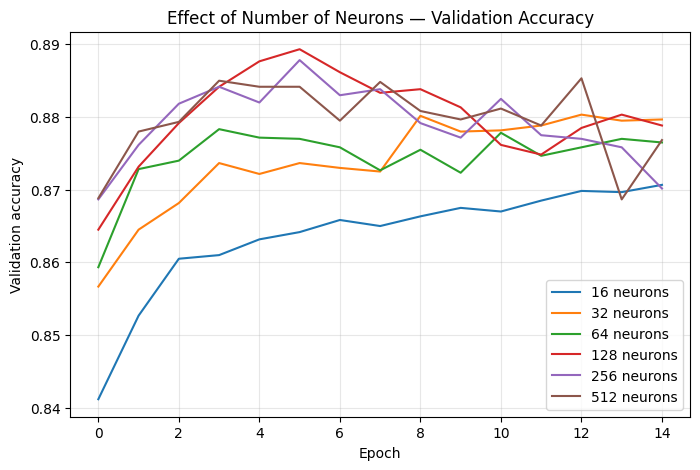

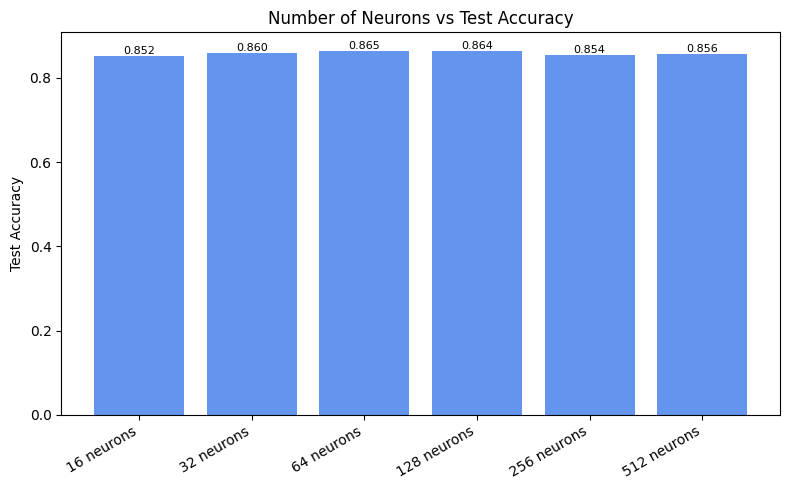

,Config,Test Accuracy,Test Loss,Train Time (s)
0,16 neurons,0.8518,0.4255,54.7
1,32 neurons,0.8601,0.3979,60.5
2,64 neurons,0.8651,0.4077,79.0
3,128 neurons,0.8638,0.4121,94.0
4,256 neurons,0.8538,0.4658,126.3
5,512 neurons,0.8563,0.4870,172.3


In [ ]:
neuron_options = [16, 32, 64, 128, 256, 512] # creating different neuron options
neuron_results = []

for n in neuron_options: #This loop goes through each value in the neuron_options list one by one.
    r = train_and_evaluate(x_train_norm, y_train, x_val_norm, y_val,
                            x_test_norm, y_test,
                            hidden_layers=[n], batch_size=32, epochs=15,
                            label=f"{n} neurons")
    neuron_results.append(r)

plot_val_curves(neuron_results, title="Effect of Number of Neurons — Validation Accuracy")
bar_compare(neuron_results, title="Number of Neurons vs Test Accuracy")
results_table(neuron_results)

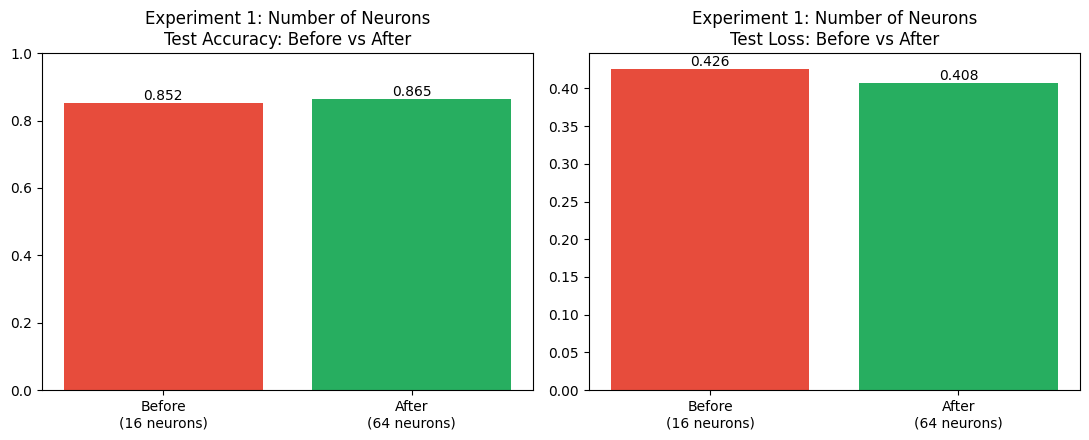

>>> 16 neurons  -->  64 neurons:  +1.33 pp accuracy change



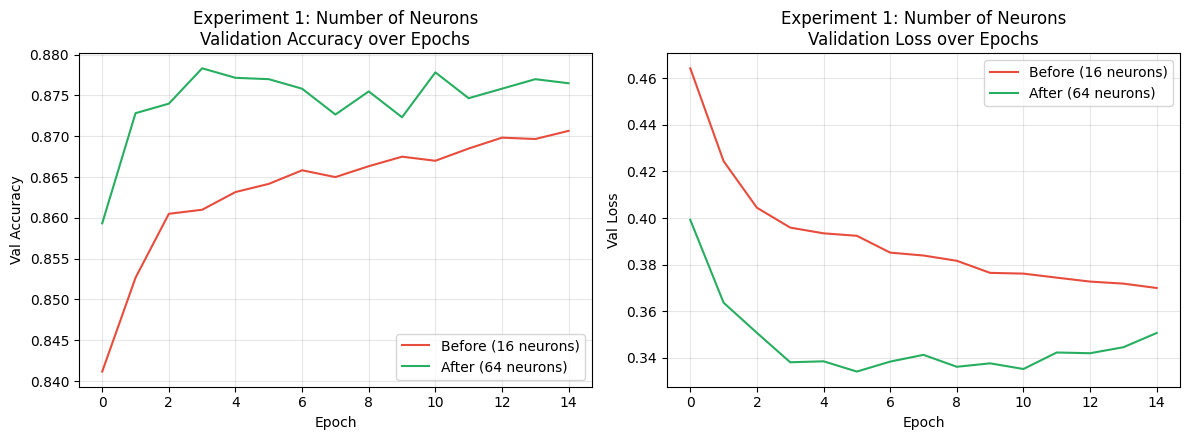

In [ ]:
# BEFORE vs AFTER
worst_n, best_n = pick_before_after(neuron_results)
before_after_compare(worst_n, best_n, title="Experiment 1: Number of Neurons")
before_after_curves(worst_n, best_n, title="Experiment 1: Number of Neurons")

#**Step 8:** Experimenting with Different Batch Sizes

The purpose of this code is to test different batch sizes and find out which batch size gives the best performance for the neural network.

[             batch=8]  Test Acc: 0.8651  |  Test Loss: 0.4807  |  Time: 346.9s
[            batch=16]  Test Acc: 0.8653  |  Test Loss: 0.4259  |  Time: 185.1s
[            batch=32]  Test Acc: 0.8568  |  Test Loss: 0.4368  |  Time: 96.9s
[            batch=64]  Test Acc: 0.8701  |  Test Loss: 0.3821  |  Time: 54.9s
[           batch=128]  Test Acc: 0.8784  |  Test Loss: 0.3540  |  Time: 34.6s
[           batch=256]  Test Acc: 0.8755  |  Test Loss: 0.3572  |  Time: 22.6s


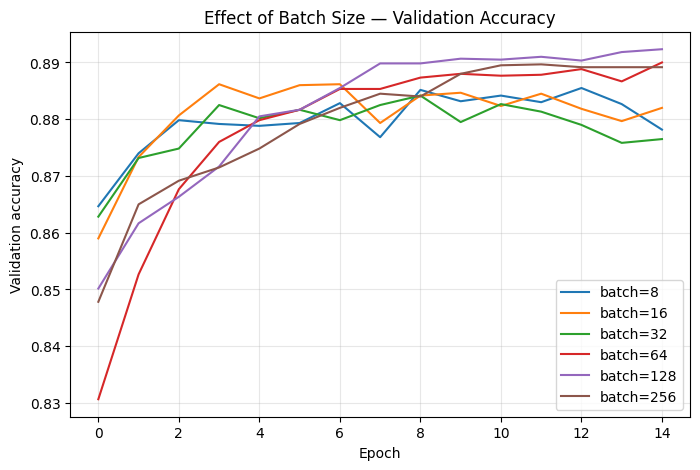

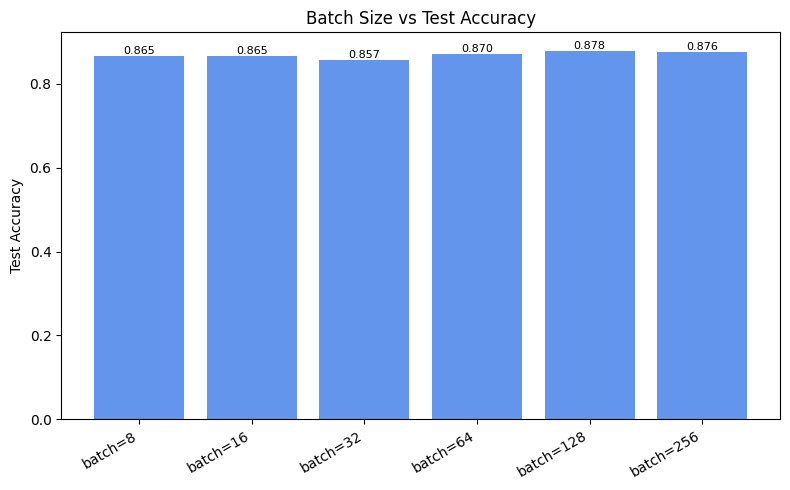

,Config,Test Accuracy,Test Loss,Train Time (s)
0,batch=8,0.8651,0.4807,346.9
1,batch=16,0.8653,0.4259,185.1
2,batch=32,0.8568,0.4368,96.9
3,batch=64,0.8701,0.3821,54.9
4,batch=128,0.8784,0.3540,34.6
5,batch=256,0.8755,0.3572,22.6


In [ ]:
BEST_NEURONS = 128  # update this after checking Step 7's winning bar

batch_options = [8, 16, 32, 64, 128, 256] # This creates a list of different batch sizes that we want to test.
batch_results = []

for b in batch_options:
    r = train_and_evaluate(x_train_norm, y_train, x_val_norm, y_val,
                            x_test_norm, y_test,
                            hidden_layers=[BEST_NEURONS], batch_size=b, epochs=15,
                            label=f"batch={b}")
    batch_results.append(r)

plot_val_curves(batch_results, title="Effect of Batch Size — Validation Accuracy")
bar_compare(batch_results, title="Batch Size vs Test Accuracy")
results_table(batch_results)

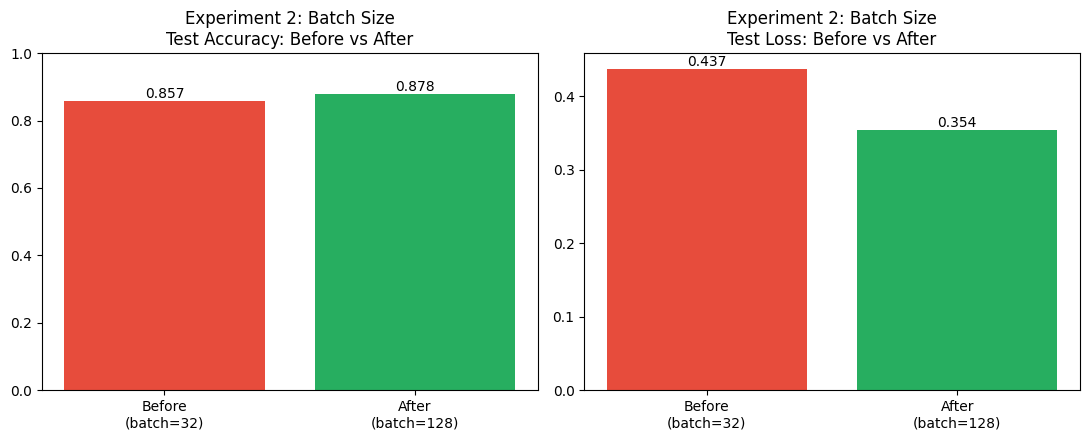

>>> batch=32  -->  batch=128:  +2.16 pp accuracy change



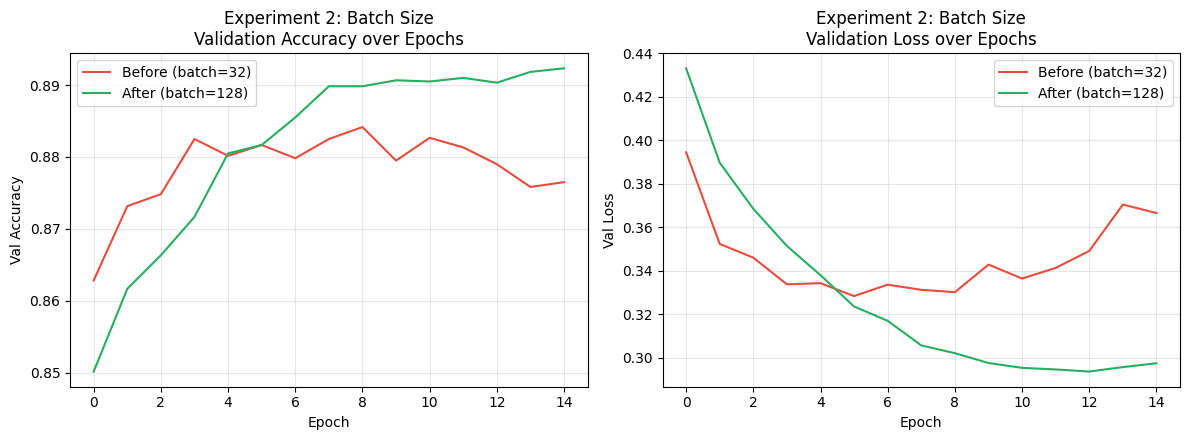

In [ ]:
# BEFORE vs AFTER
worst_b, best_b = pick_before_after(batch_results)
before_after_compare(worst_b, best_b, title="Experiment 2: Batch Size")
before_after_curves(worst_b, best_b, title="Experiment 2: Batch Size")

#**Step 9:** Experimenting with Different Numbers of Hidden Layers

[             1 layer]  Test Acc: 0.8639  |  Test Loss: 0.4198  |  Time: 94.3s
[            2 layers]  Test Acc: 0.8775  |  Test Loss: 0.3855  |  Time: 105.8s
[            3 layers]  Test Acc: 0.8680  |  Test Loss: 0.3985  |  Time: 107.6s
[            4 layers]  Test Acc: 0.8557  |  Test Loss: 0.4345  |  Time: 110.9s
[            5 layers]  Test Acc: 0.8656  |  Test Loss: 0.3975  |  Time: 112.3s


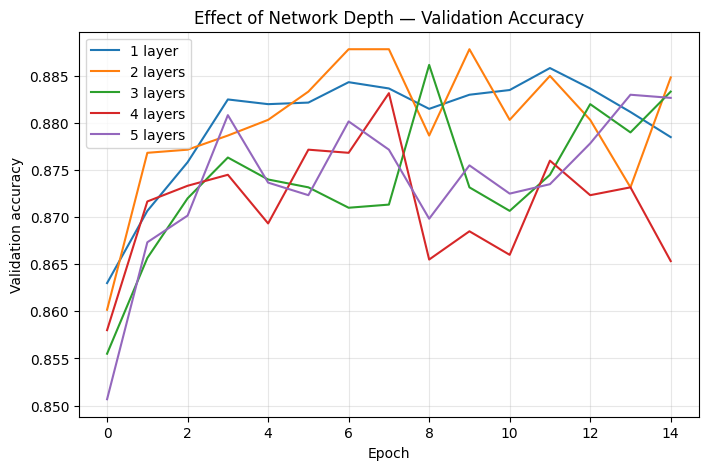

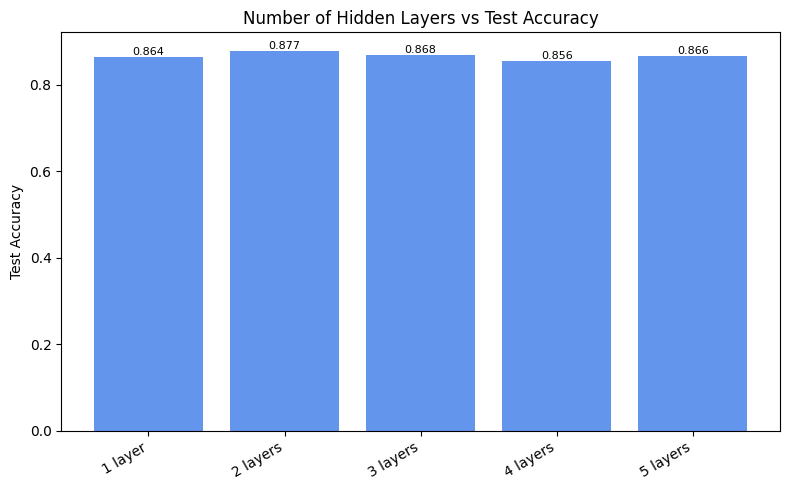

,Config,Test Accuracy,Test Loss,Train Time (s)
0,1 layer,0.8639,0.4198,94.3
1,2 layers,0.8775,0.3855,105.8
2,3 layers,0.8680,0.3985,107.6
3,4 layers,0.8557,0.4345,110.9
4,5 layers,0.8656,0.3975,112.3


In [ ]:
BEST_BATCH = 32  # update after checking Step 8's winning bar

depth_configs = {
    "1 layer":  [128],
    "2 layers": [128, 64],
    "3 layers": [128, 64, 32],
    "4 layers": [128, 64, 32, 16],
    "5 layers": [128, 64, 32, 16, 8],
}

depth_results = []
for label, layers_cfg in depth_configs.items():
    r = train_and_evaluate(x_train_norm, y_train, x_val_norm, y_val,
                            x_test_norm, y_test,
                            hidden_layers=layers_cfg, batch_size=BEST_BATCH, epochs=15,
                            label=label)
    depth_results.append(r)

plot_val_curves(depth_results, title="Effect of Network Depth — Validation Accuracy")
bar_compare(depth_results, title="Number of Hidden Layers vs Test Accuracy")
results_table(depth_results)

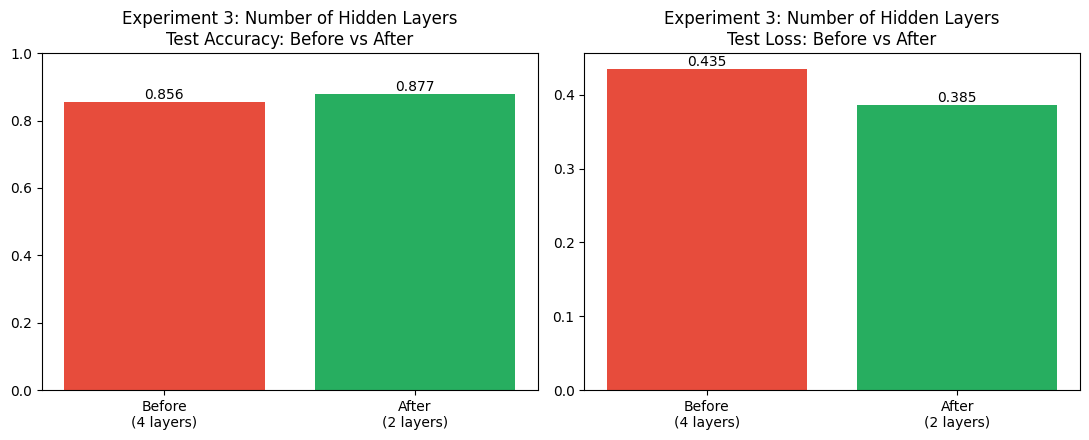

>>> 4 layers  -->  2 layers:  +2.18 pp accuracy change



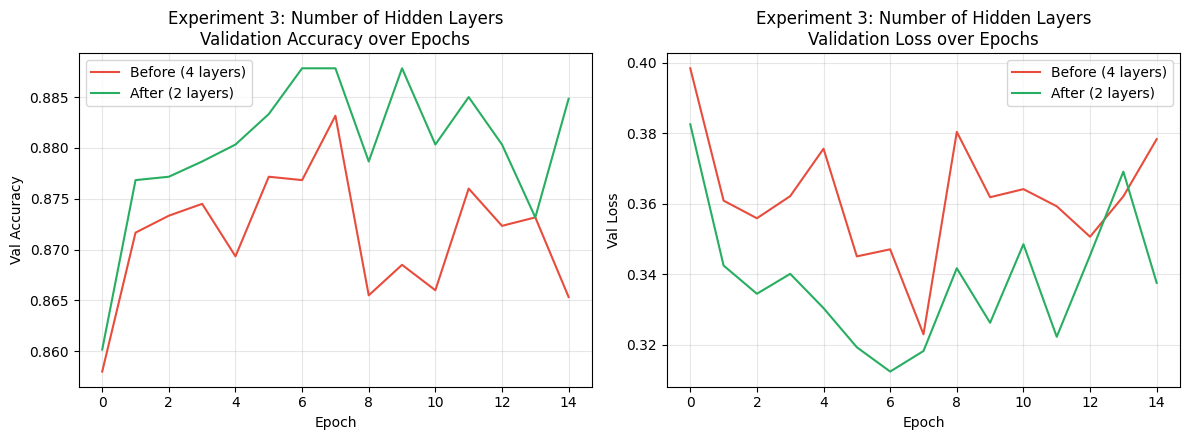

In [ ]:
# BEFORE vs AFTER
worst_d, best_d = pick_before_after(depth_results)
before_after_compare(worst_d, best_d, title="Experiment 3: Number of Hidden Layers")
before_after_curves(worst_d, best_d, title="Experiment 3: Number of Hidden Layers")

#**Step 10:** Effect of Regularization Techniques on Neural Network Performance

[   No Regularization]  Test Acc: 0.8848  |  Test Loss: 0.4906  |  Time: 287.2s
[         Dropout 0.3]  Test Acc: 0.8748  |  Test Loss: 0.3588  |  Time: 296.3s
[         Dropout 0.5]  Test Acc: 0.8699  |  Test Loss: 0.3764  |  Time: 306.6s
[          L1 (0.001)]  Test Acc: 0.8328  |  Test Loss: 0.6377  |  Time: 340.9s
[          L2 (0.001)]  Test Acc: 0.8598  |  Test Loss: 0.4638  |  Time: 315.6s
[             L1 + L2]  Test Acc: 0.8311  |  Test Loss: 0.6540  |  Time: 378.8s


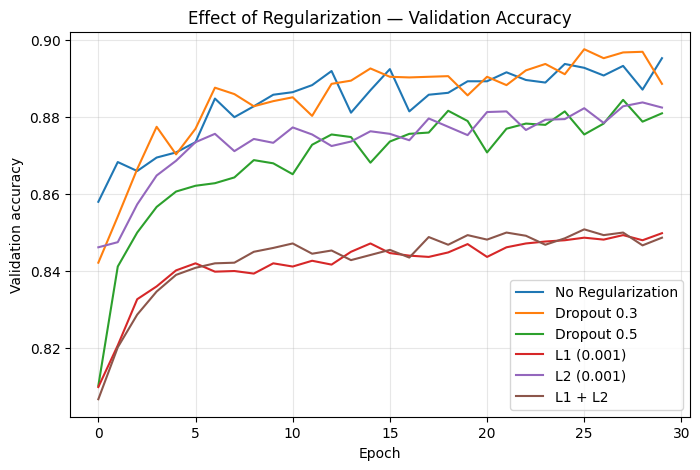

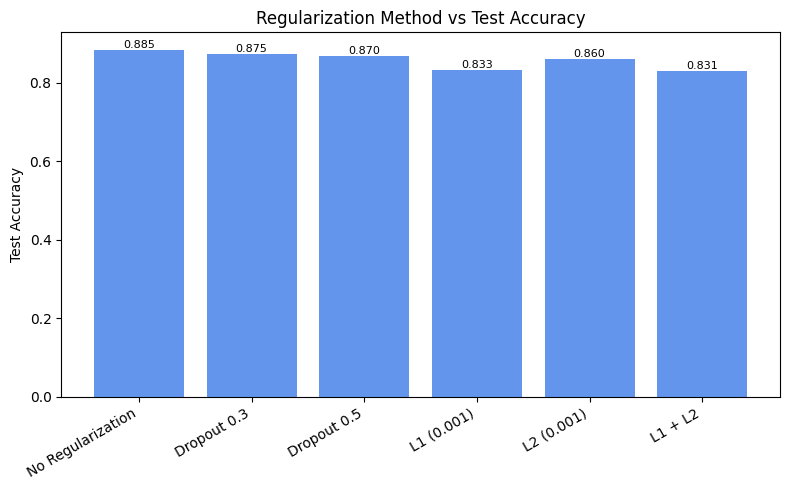

,Config,Test Accuracy,Test Loss,Train Time (s)
0,No Regularization,0.8848,0.4906,287.2
1,Dropout 0.3,0.8748,0.3588,296.3
2,Dropout 0.5,0.8699,0.3764,306.6
3,L1 (0.001),0.8328,0.6377,340.9
4,L2 (0.001),0.8598,0.4638,315.6
5,L1 + L2,0.8311,0.6540,378.8


In [ ]:
REG_ARCH = [256, 128, 64] #This defines the structure of the hidden layers. We have 3 hidden  layers with 256, 128 and 68 neurons.
REG_EPOCHS = 30 #This means each model will be trained for 30 epochs.

reg_configs = {
    "No Regularization": dict(dropout_rate=0.0, l1_reg=0.0, l2_reg=0.0),
    "Dropout 0.3":        dict(dropout_rate=0.3, l1_reg=0.0, l2_reg=0.0),
    "Dropout 0.5":        dict(dropout_rate=0.5, l1_reg=0.0, l2_reg=0.0),
    "L1 (0.001)":         dict(dropout_rate=0.0, l1_reg=0.001, l2_reg=0.0),
    "L2 (0.001)":         dict(dropout_rate=0.0, l1_reg=0.0, l2_reg=0.001),
    "L1 + L2":            dict(dropout_rate=0.0, l1_reg=0.001, l2_reg=0.001),
}

reg_results = []
for label, cfg in reg_configs.items():
    r = train_and_evaluate(x_train_norm, y_train, x_val_norm, y_val,
                            x_test_norm, y_test,
                            hidden_layers=REG_ARCH, batch_size=BEST_BATCH,
                            epochs=REG_EPOCHS, label=label, **cfg)
    reg_results.append(r)

plot_val_curves(reg_results, title="Effect of Regularization — Validation Accuracy")
bar_compare(reg_results, title="Regularization Method vs Test Accuracy")
results_table(reg_results)

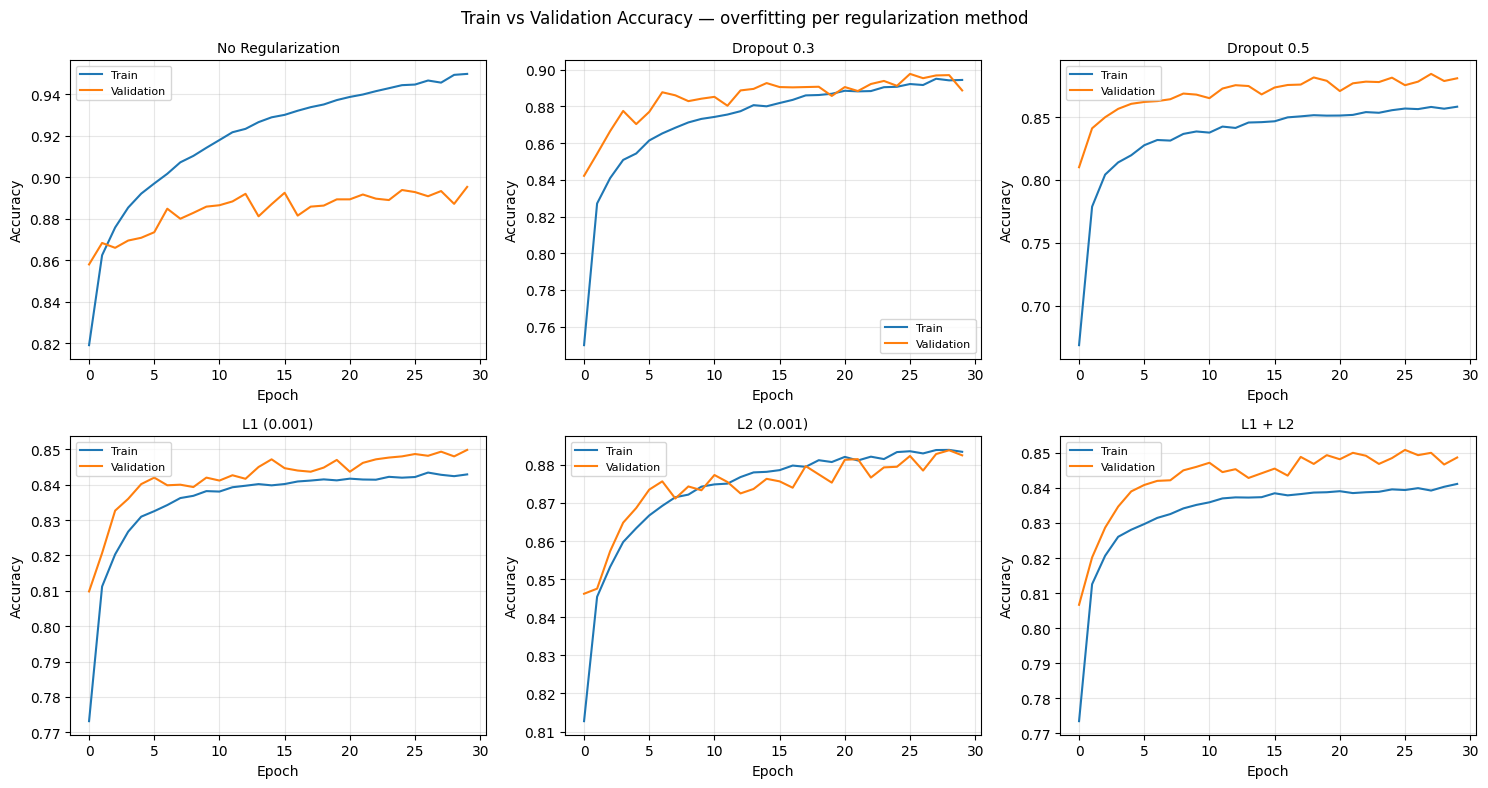

In [ ]:
# Train vs Validation accuracy per method — this IS the overfitting story
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, r in zip(axes.flat, reg_results):
    ax.plot(r['history']['accuracy'], label='Train')
    ax.plot(r['history']['val_accuracy'], label='Validation')
    ax.set_title(r['label'], fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("Train vs Validation Accuracy — overfitting per regularization method")
plt.tight_layout()
plt.show()

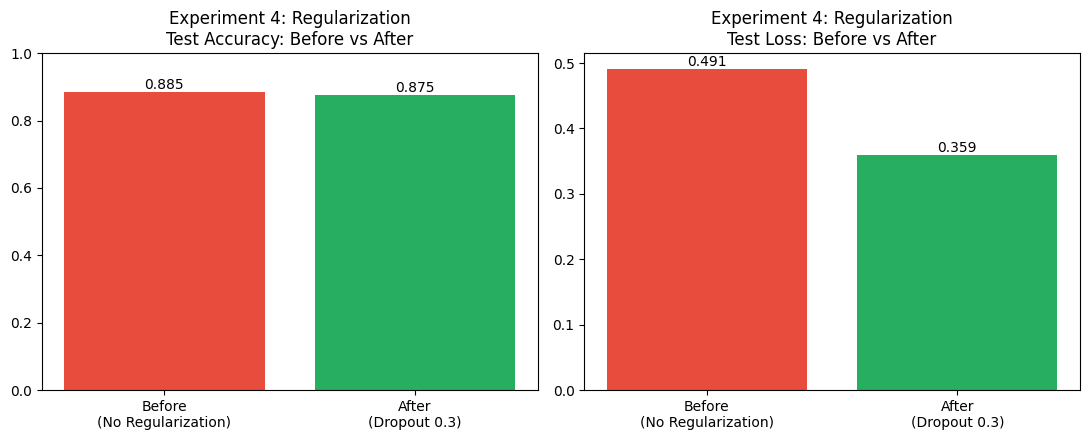

>>> No Regularization  -->  Dropout 0.3:  -1.00 pp accuracy change



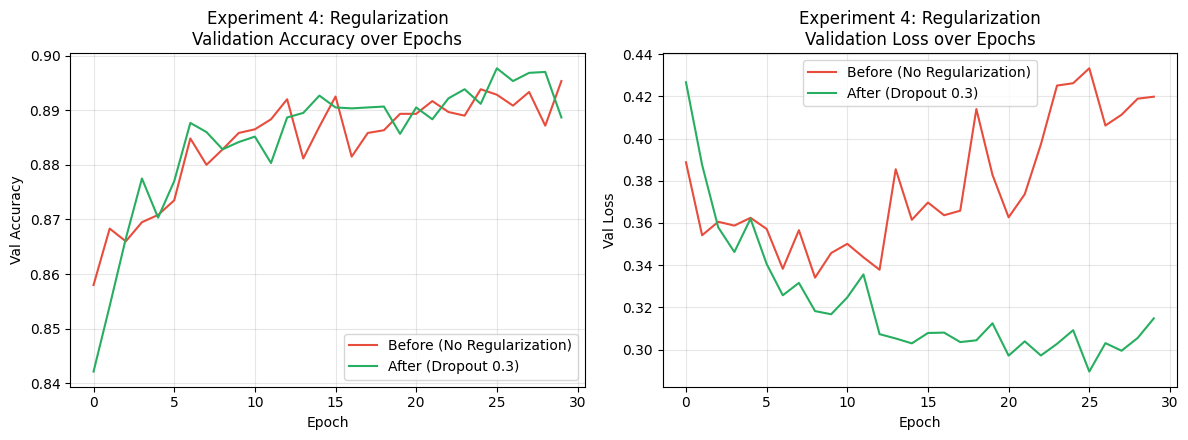

Train-Val accuracy GAP before (no reg): 0.054
Train-Val accuracy GAP after (Dropout 0.3): 0.006
Overfitting reduced by 4.87 percentage points


In [ ]:
# BEFORE (no regularization) vs AFTER (best regularized config)
no_reg = reg_results[0]
best_reg = max(reg_results[1:], key=lambda r: r['test_acc'])
before_after_compare(no_reg, best_reg, title="Experiment 4: Regularization")
before_after_curves(no_reg, best_reg, title="Experiment 4: Regularization")

gap_before = reg_results[0]['history']['accuracy'][-1] - reg_results[0]['history']['val_accuracy'][-1]
gap_after  = best_reg['history']['accuracy'][-1] - best_reg['history']['val_accuracy'][-1]
print(f"Train-Val accuracy GAP before (no reg): {gap_before:.3f}")
print(f"Train-Val accuracy GAP after ({best_reg['label']}): {gap_after:.3f}")
print(f"Overfitting reduced by {(gap_before - gap_after)*100:.2f} percentage points")

#**Step 11:** Comparing Feature Scaling Methods (Raw vs. Min-Max vs. Standardized)

[         Raw (0-255)]  Test Acc: 0.8387  |  Test Loss: 0.4772  |  Time: 106.9s
[       Min-Max (0-1)]  Test Acc: 0.8708  |  Test Loss: 0.4101  |  Time: 112.1s
[Standardized (z-score)]  Test Acc: 0.8659  |  Test Loss: 0.5989  |  Time: 100.3s


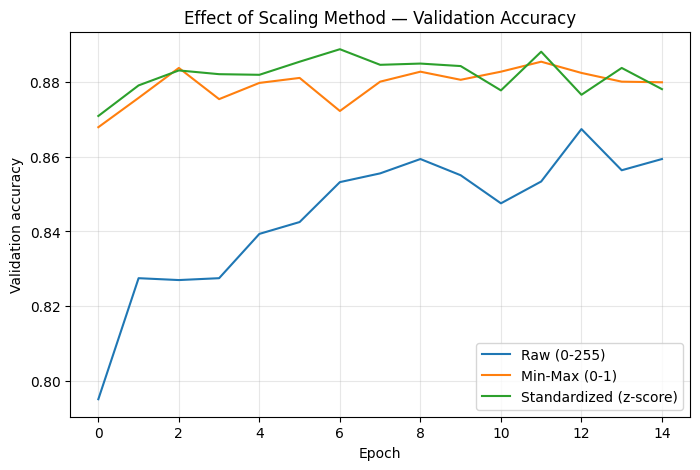

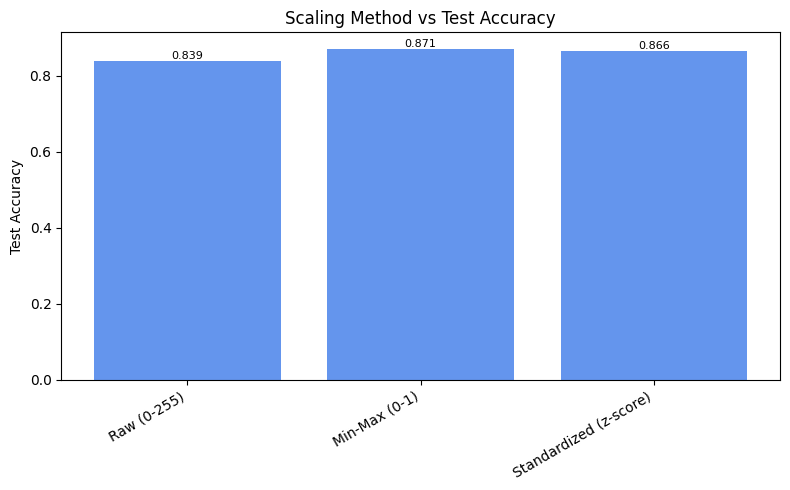

,Config,Test Accuracy,Test Loss,Train Time (s)
0,Raw (0-255),0.8387,0.4772,106.9
1,Min-Max (0-1),0.8708,0.4101,112.1
2,Standardized (z-score),0.8659,0.5989,100.3


In [ ]:
x_train_raw = x_train_flat
x_val_raw   = x_val_flat
x_test_raw  = x_test_flat

scaler = StandardScaler() #Creating standardized (z-score) data
x_train_std = scaler.fit_transform(x_train_flat)
x_val_std   = scaler.transform(x_val_flat)
x_test_std  = scaler.transform(x_test_flat)
# Organizing all three scaling versions into one dictionary
scaling_datasets = {
    "Raw (0-255)":            (x_train_raw, x_val_raw, x_test_raw),
    "Min-Max (0-1)":           (x_train_norm, x_val_norm, x_test_norm),
    "Standardized (z-score)":  (x_train_std, x_val_std, x_test_std),
}

FINAL_ARCH = [128, 64]  # your best architecture from Step 9

scaling_results = []
for label, (xtr, xva, xte) in scaling_datasets.items():
    r = train_and_evaluate(xtr, y_train, xva, y_val, xte, y_test,
                            hidden_layers=FINAL_ARCH, batch_size=BEST_BATCH,
                            epochs=15, label=label)
    scaling_results.append(r)

plot_val_curves(scaling_results, title="Effect of Scaling Method — Validation Accuracy")
bar_compare(scaling_results, title="Scaling Method vs Test Accuracy")
results_table(scaling_results)

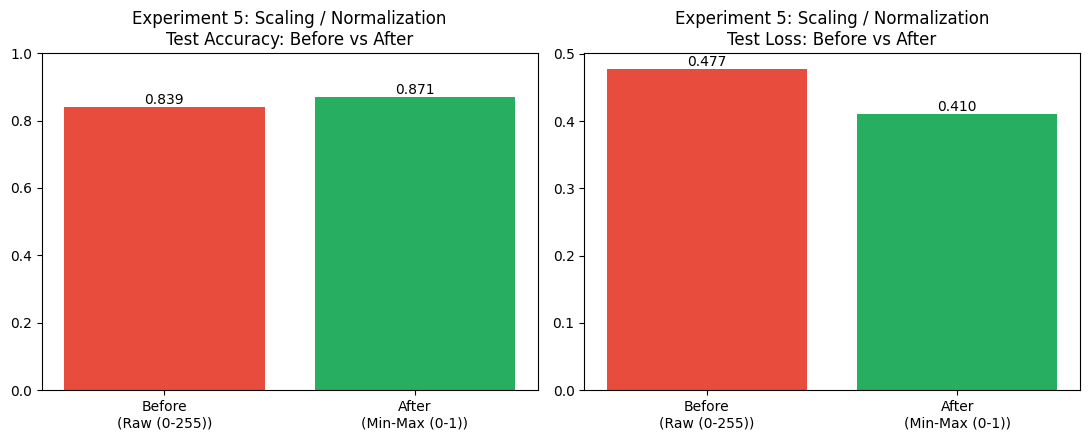

>>> Raw (0-255)  -->  Min-Max (0-1):  +3.21 pp accuracy change



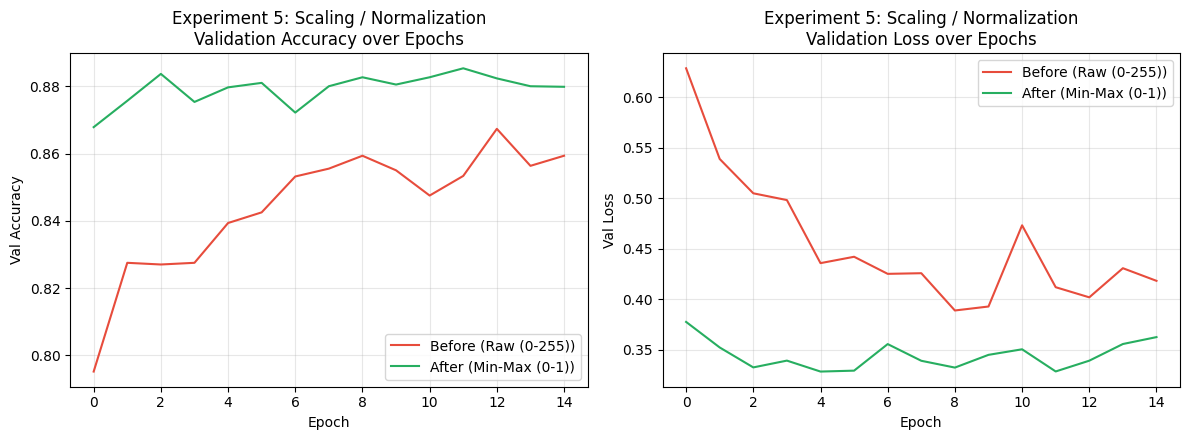

In [ ]:
# BEFORE vs AFTER
worst_s, best_s = pick_before_after(scaling_results)
before_after_compare(worst_s, best_s, title="Experiment 5: Scaling / Normalization")
before_after_curves(worst_s, best_s, title="Experiment 5: Scaling / Normalization")

#**Step 12:** Building and Evaluating the Final Tuned Model

[   Final Tuned Model]  Test Acc: 0.8776  |  Test Loss: 0.3472  |  Time: 144.9s


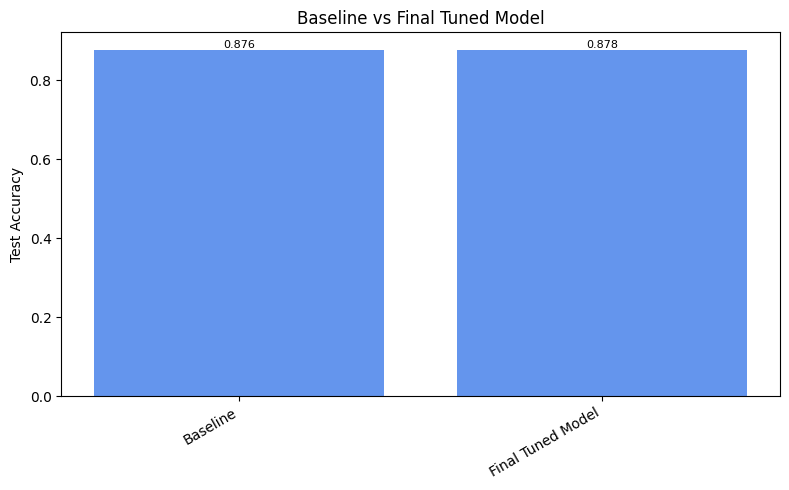


Improvement over baseline: 0.13 percentage points


In [ ]:
FINAL_LAYERS    = [128, 64]
FINAL_BATCH     = 32
FINAL_DROPOUT   = 0.3
FINAL_L2        = 0.0
FINAL_SCALING   = (x_train_norm, x_val_norm, x_test_norm)  # or the _std versions

xtr, xva, xte = FINAL_SCALING

final_model_result = train_and_evaluate(xtr, y_train, xva, y_val, xte, y_test,
                                         hidden_layers=FINAL_LAYERS,
                                         dropout_rate=FINAL_DROPOUT,
                                         l2_reg=FINAL_L2,
                                         batch_size=FINAL_BATCH,
                                         epochs=20, label="Final Tuned Model")

comparison = [baseline, final_model_result] #Comparing the final model against the original baseline
bar_compare(comparison, title="Baseline vs Final Tuned Model")
results_table(comparison)

improvement = (final_model_result['test_acc'] - baseline['test_acc']) * 100
print(f"\nImprovement over baseline: {improvement:.2f} percentage points")

#**Step 12:** Summary — Before vs. After Comparison Across All Tuning Factors

                    Factor  Before (worst)  After (best)  Improvement (pp)
      1. Number of Neurons          0.8518        0.8651          1.330000
             2. Batch Size          0.8568        0.8784          2.160001
3. Number of Hidden Layers          0.8557        0.8775          2.179998
         4. Regularization          0.8848        0.8748         -0.999999
  5. Scaling/Normalization          0.8387        0.8708          3.210002


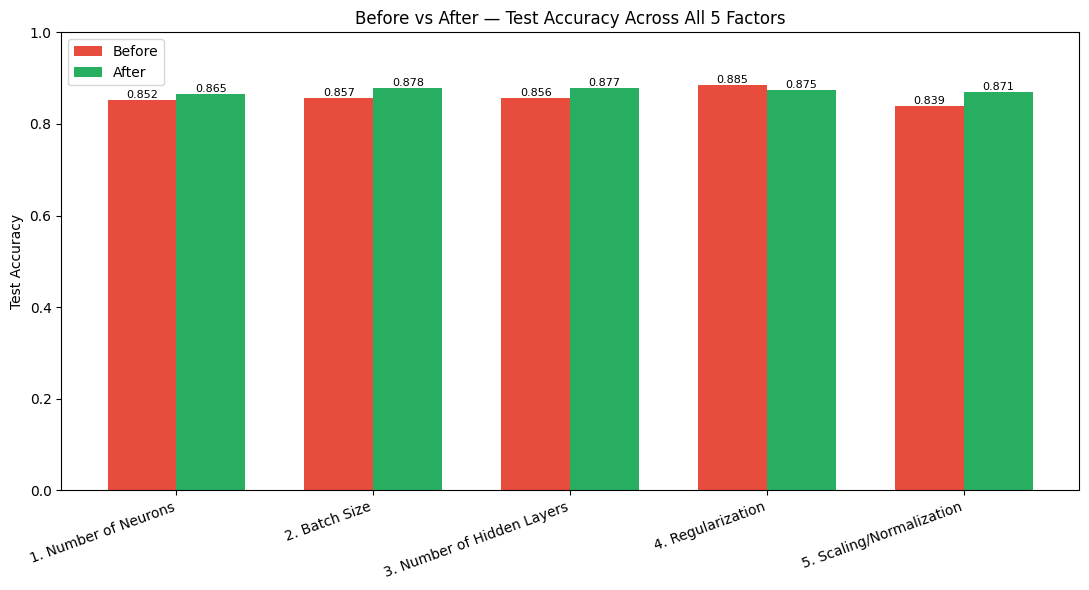

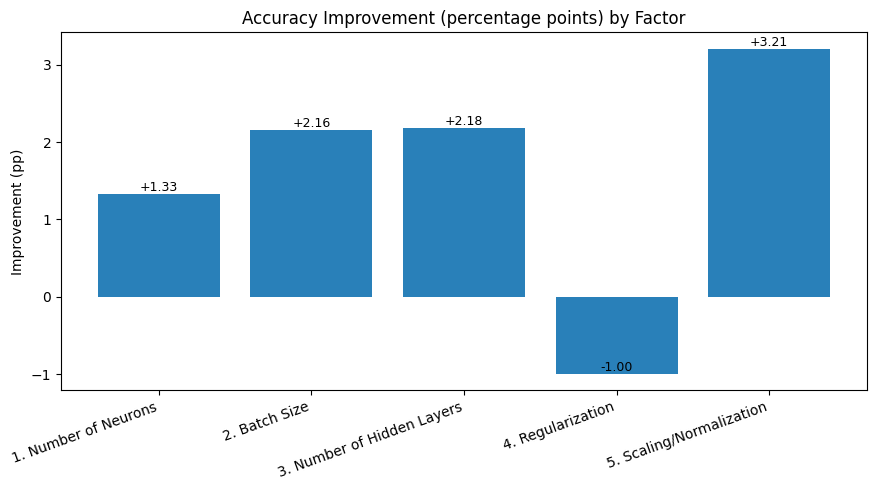

In [ ]:
summary_rows = []

def add_summary(name, worst, best):
    summary_rows.append({
        "Factor": name,
        "Before (worst)": worst['test_acc'],
        "After (best)": best['test_acc'],
        "Improvement (pp)": (best['test_acc'] - worst['test_acc']) * 100
    })
# Filling in the summary for each of the 5 tuning factors
add_summary("1. Number of Neurons", *pick_before_after(neuron_results))
add_summary("2. Batch Size", *pick_before_after(batch_results))
add_summary("3. Number of Hidden Layers", *pick_before_after(depth_results))
add_summary("4. Regularization", reg_results[0], max(reg_results[1:], key=lambda r: r['test_acc']))
add_summary("5. Scaling/Normalization", *pick_before_after(scaling_results))
# Creating and printing the summary table
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
# Setting up the bar chart
x = np.arange(len(summary_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, summary_df["Before (worst)"], width, label="Before", color="#e74c3c")
bars2 = ax.bar(x + width/2, summary_df["After (best)"], width, label="After", color="#27ae60")
ax.set_ylabel("Test Accuracy")
ax.set_title("Before vs After — Test Accuracy Across All 5 Factors")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["Factor"], rotation=20, ha='right')
ax.legend()
ax.set_ylim(0, 1)
for b in list(bars1) + list(bars2):
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f"{h:.3f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
bars = plt.bar(summary_df["Factor"], summary_df["Improvement (pp)"], color="#2980b9")
plt.title("Accuracy Improvement (percentage points) by Factor")
plt.ylabel("Improvement (pp)")
plt.xticks(rotation=20, ha='right')
for b, v in zip(bars, summary_df["Improvement (pp)"]):
    plt.text(b.get_x() + b.get_width()/2, v, f"{v:+.2f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()